# Hyperparameter Tuning & Model Performance Report

## 1. Project Overview
This notebook implements an automated machine learning pipeline focused on optimizing regression models for price prediction. The process employs Optuna for systematic hyperparameter search to minimize validation error, ensuring the selection of the most effective architecture among Random Forest, XGBoost, and Extra Trees.

## 2. Methodology
The development pipeline is divided into three key stages to maintain statistical rigor:
1.  **Optimization:** Comparative hyperparameter tuning using Optuna to identify the ideal configuration.
2.  **Pipeline Construction:** Developing a leak-proof training pipeline incorporating the best-found parameters.
3.  **Holdout Validation:** Evaluating the finalized model on a completely unseen test dataset to determine real-world predictive performance.

## 3. Optimization Results
The optimization process identified **XGBoost** as the superior model.

### Best Hyperparameters (XGBoost)
| Hyperparameter | Value |
| :--- | :--- |
| `n_estimators` | 500 |
| `learning_rate` | 0.040122 |
| `max_depth` | 7 |
| `subsample` | 0.744823 |
| `colsample_bytree` | 0.802728 |
| `reg_alpha` | 0.108478 |
| `reg_lambda` | 0.018410 |

## 4. Performance Metrics

The model was fitted using the complete, leak-proof pipeline on the training set and subsequently tested on the holdout data.

### Data Split Summary
*   **Training Set:** 2,843 rows
*   **Test Holdout Set:** 711 rows

### Final Evaluation 
| Metric | Result |
| :--- | :--- |
| **Mean Absolute Error (MAE)** | **0.4182 Crores** |
| **$R^2$ Score (Variance Explained)** | **0.8307** |

---
*End of Report*

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import category_encoders as ce

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

In [6]:
# !pip install optuna category_encoders

In [4]:
df = pd.read_csv(r'../data/processed/gurgaon_properties_post_feature_selection_v2.csv')

In [5]:
df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,floor_category,luxury_category,price
0,house,sector 5,2,2,1,Old Property,900.0,0,0,semifurnished,Low-Rise,Standard,0.80
1,flat,sector 104,3,2,3+,Relatively New,1607.0,0,0,unfurnished,High-Rise,Luxury,1.20
2,flat,sector 52,5,7,3+,Moderately Old,5778.0,1,0,semifurnished,Low-Rise,Premium,5.00
3,house,sector 22,7,5,3+,Old Property,2367.0,0,0,unfurnished,Low-Rise,Standard,4.75
4,flat,sohna road,2,2,3,New Property,913.0,0,0,semifurnished,Low-Rise,Premium,0.56


In [6]:
X = df.drop('price' , axis=1)
y = df['price']

In [7]:
def objective(trial, X, y):
    """
    Optuna objective function. Models train on log1p targets, 
    but cross-validation evaluates errors strictly in the actual price space.
    """
    
    # -------------------------------------------------------------------------
    # 1. ALGORITHM TOURNAMENT CONFIGURATION
    # -------------------------------------------------------------------------
    regressor_name = trial.suggest_categorical('regressor_name', ['RandomForest', 'XGBoost', 'ExtraTrees'])
    
    if regressor_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('rf_n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('rf_max_depth', 10, 30),
            'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('rf_max_features', ['sqrt', 0.7, 0.8]),
            'random_state': 42,
            'n_jobs': -1
        }
        base_model = RandomForestRegressor(**params)
        
    elif regressor_name == 'ExtraTrees':
        params = {
            'n_estimators': trial.suggest_int('et_n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('et_max_depth', 10, 35),
            'min_samples_split': trial.suggest_int('et_min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('et_min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('et_max_features', ['sqrt', 0.8, 0.9]),
            'random_state': 42,
            'n_jobs': -1
        }
        base_model = ExtraTreesRegressor(**params)
        
    elif regressor_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 500, step=100),
            'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('xgb_max_depth', 5, 12),
            'subsample': trial.suggest_float('xgb_subsample', 0.7, 0.9),
            'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.7, 0.9),
            'reg_alpha': trial.suggest_float('xgb_reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('xgb_reg_lambda', 1e-3, 10.0, log=True),
            'random_state': 42,
            'n_jobs': -1
        }
        base_model = xgb.XGBRegressor(**params)

    # -------------------------------------------------------------------------
    # 2. FEATURE PREPROCESSING (LEAK-PROOF TARGET ENCODING)
    # -------------------------------------------------------------------------
    target_columns_to_encode = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), target_columns_to_encode),
            ('cat1', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['agePossession']),
            ('target_enc', ce.TargetEncoder(), ['sector']) 
        ], 
        remainder='passthrough'
    )
    
    # -------------------------------------------------------------------------
    # 3. TARGET SPACE MANAGEMENT
    # -------------------------------------------------------------------------
    wrapped_regressor = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', wrapped_regressor)
    ])
    
    # -------------------------------------------------------------------------
    # 4. CROSS VALIDATION IN THE ACTUAL SPACE
    # -------------------------------------------------------------------------
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(
        pipeline, X, y, 
        cv=kf, 
        scoring='neg_mean_absolute_error', 
        n_jobs=1
    )
    
    return -np.mean(scores)

In [8]:
study = optuna.create_study(direction='minimize')

[I 2026-07-19 10:25:16,091] A new study created in memory with name: no-name-d25bde69-c4b9-4f49-ac03-95431f2053e1


In [9]:
study.optimize(lambda trial: objective(trial, X, y), n_trials=50)

[I 2026-07-19 10:25:25,518] Trial 0 finished with value: 0.5074066219261189 and parameters: {'regressor_name': 'ExtraTrees', 'et_n_estimators': 500, 'et_max_depth': 16, 'et_min_samples_split': 4, 'et_min_samples_leaf': 2, 'et_max_features': 0.8}. Best is trial 0 with value: 0.5074066219261189.
[I 2026-07-19 10:25:36,236] Trial 1 finished with value: 0.5396039071802707 and parameters: {'regressor_name': 'XGBoost', 'xgb_n_estimators': 300, 'xgb_learning_rate': 0.042614383333497256, 'xgb_max_depth': 12, 'xgb_subsample': 0.8231250995341511, 'xgb_colsample_bytree': 0.8877182819692272, 'xgb_reg_alpha': 5.800327509332857, 'xgb_reg_lambda': 0.8397687292251218}. Best is trial 0 with value: 0.5074066219261189.
[I 2026-07-19 10:25:40,097] Trial 2 finished with value: 0.47974011825365726 and parameters: {'regressor_name': 'RandomForest', 'rf_n_estimators': 300, 'rf_max_depth': 16, 'rf_min_samples_split': 2, 'rf_min_samples_leaf': 1, 'rf_max_features': 0.7}. Best is trial 2 with value: 0.4797401182

In [10]:
print(f"Winner Model: {study.best_params['regressor_name']}")
print(f"Best Validation MAE: {study.best_value:.4f} Crores")

# Extract the dictionary containing ONLY the hyperparameters
best_hyperparameters = study.best_params.copy()
champion_algorithm = best_hyperparameters.pop('regressor_name')

Winner Model: XGBoost
Best Validation MAE: 0.4725 Crores


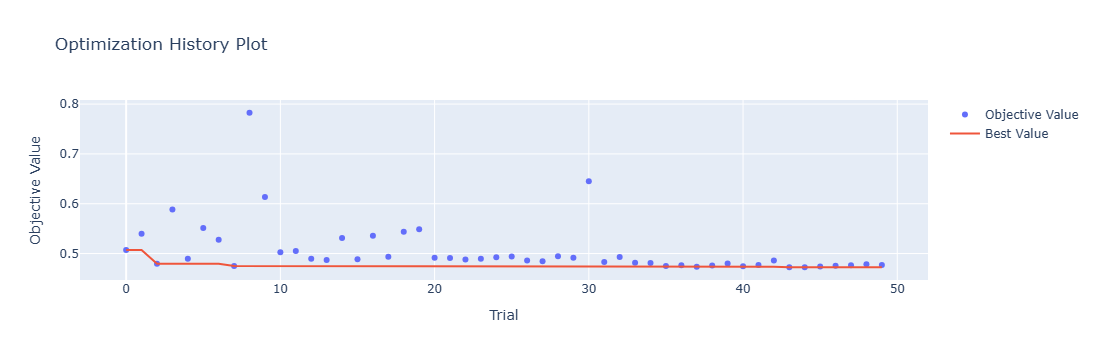

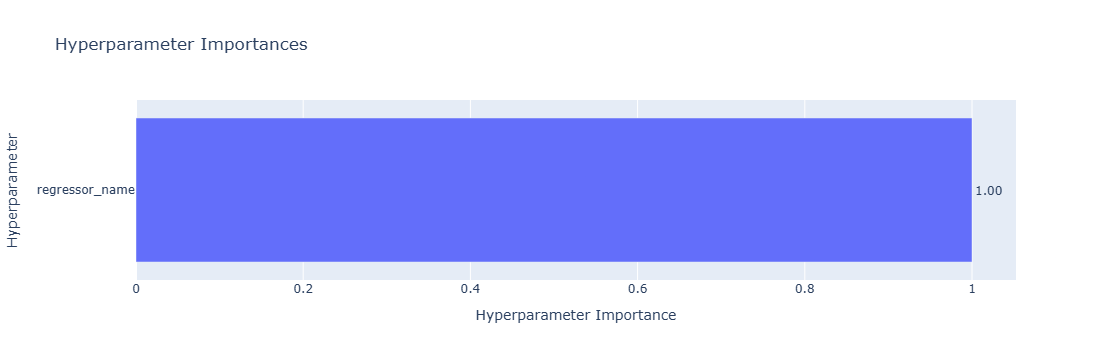

In [12]:
from optuna.visualization import plot_optimization_history, plot_param_importances

# 1. Check Convergence: Ensure the MAE curve flattened out nicely over the trials
plot_optimization_history(study).show()

# 2. Hyperparameter Importance: Find out exactly which parameter moved the needle most
plot_param_importances(study).show()

[I 2026-07-19 10:31:26,176] A new study created in memory with name: no-name-7f91030e-6562-4e33-8da7-44d8cd6f47d7


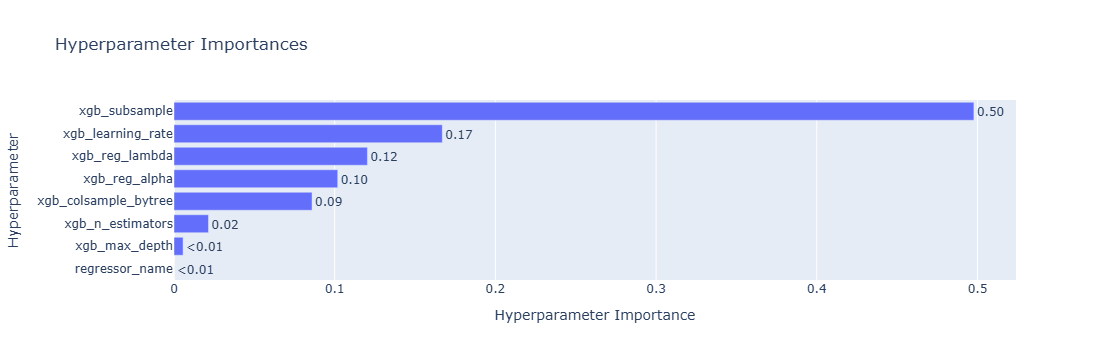

In [13]:
# 1. Identify the winning model name (e.g., 'XGBoost')
winner = study.best_params['regressor_name']

# 2. Filter out trials where only the winning model was evaluated
target_trials = [t for t in study.trials if t.params.get('regressor_name') == winner]

# 3. Create a sub-study container to force Optuna to focus strictly on those trials
sub_study = optuna.study.create_study(direction="minimize")
sub_study.add_trials(target_trials)

# 4. Re-plot the hyperparameter importances for clean, isolated insight
optuna.visualization.plot_param_importances(sub_study).show()

In [14]:
study.best_params

{'regressor_name': 'XGBoost',
 'xgb_n_estimators': 500,
 'xgb_learning_rate': 0.04012240724057226,
 'xgb_max_depth': 7,
 'xgb_subsample': 0.7448228969369078,
 'xgb_colsample_bytree': 0.8027275970188548,
 'xgb_reg_alpha': 0.10847831041061963,
 'xgb_reg_lambda': 0.01840970025222743}

### Final Test with selected model and setting

In [15]:
import numpy as np
import pandas as pd
import xgboost as xgb
import category_encoders as ce

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score


# Standard 80/20 train-test split with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"[INFO] Training set size: {X_train.shape[0]} rows")
print(f"[INFO] Test holdout set size: {X_test.shape[0]} rows")

# =============================================================================
# 2. DEFINING THE CHAMPION PIPELINE COMPONENTS
# =============================================================================

# A. Your exact feature preprocessing matrix
target_columns_to_encode = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), target_columns_to_encode),
        ('cat1', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector']) 
    ], 
    remainder='passthrough'
)

# B. Hardcoding your exact optimized XGBoost parameters from Optuna
champion_hyperparameters = {
    'n_estimators': 500,
    'learning_rate': 0.04012240724057226,
    'max_depth': 7,
    'subsample':  0.7448228969369078,
    'colsample_bytree': 0.8027275970188548,
    'reg_alpha': 0.10847831041061963,
    'reg_lambda': 0.01840970025222743,
    'random_state': 42,
    'n_jobs': -1
}

base_xgb_model = xgb.XGBRegressor(**champion_hyperparameters)

# C. Wrapping the regressor to automatically handle the log1p -> expm1 transformation
wrapped_regressor = TransformedTargetRegressor(
    regressor=base_xgb_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# D. Assembling the linear production pipeline
final_production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', wrapped_regressor)
])

# =============================================================================
# 3. TRAINING & EVALUATION
# =============================================================================
print("[TRAIN] Fitting the complete leak-proof pipeline on X_train...")
# The preprocessor scales/encodes; the regressor trains smoothly in log space
final_production_pipeline.fit(X_train, y_train)
print("[SUCCESS] Model training complete.")

print("[PREDICT] Generating predictions on the completely unseen test split...")
# The pipeline automatically transforms text categories and maps log outputs back to Crores
y_pred = final_production_pipeline.predict(X_test)

# Calculate performance metrics strictly in the real price scale
final_mae = mean_absolute_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("          FINAL OUT-OF-SAMPLE METRICS")
print("="*50)
print(f"Final Test Mean Absolute Error (MAE) : {final_mae:.4f} Crores")
print(f"Final Test R² Score (Variance Explained): {final_r2:.4f}")
print("="*50)

[INFO] Training set size: 2843 rows
[INFO] Test holdout set size: 711 rows
[TRAIN] Fitting the complete leak-proof pipeline on X_train...
[SUCCESS] Model training complete.
[PREDICT] Generating predictions on the completely unseen test split...

          FINAL OUT-OF-SAMPLE METRICS
Final Test Mean Absolute Error (MAE) : 0.4182 Crores
Final Test R² Score (Variance Explained): 0.8307


### Tring out Predictions

In [23]:
test = pd.read_csv(r'../testfolder/gemini-code-1784438764358.csv')

In [77]:
import numpy as np
import pandas as pd

# =============================================================================
# 1. DEFINE ACTUAL HISTORICAL TEST RECORDS
# =============================================================================
columns = [
    'property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
    'agePossession', 'built_up_area', 'servant room', 'store room',
    'furnishing_type', 'luxury_category', 'floor_category'
]

scraped_validation_data = test.drop('actual_price_cr' , axis=1)

y_true_actual = test['actual_price_cr']
# Wrap test cases into an inference DataFrame
test_features_df = pd.DataFrame(scraped_validation_data, columns=columns)

# =============================================================================
# 2. RUN PIPELINE INFERENCE & CALCULATE ERROR VOLATILITY
# =============================================================================
# Assuming 'final_production_pipeline' is trained and loaded in your local workspace
y_pred_inference = final_production_pipeline.predict(test_features_df)

# Initialize data structures to compile variance results
calculated_rows = []
error_magnitudes = []

# Baseline validation matrix metrics from your Optuna tournament models
MODEL_MAE = 0.4725

for i in range(len(y_true_actual)):
    actual = y_true_actual[i]
    pred = y_pred_inference[i]
    
    # Mathematical error matrix calculations
    variance = pred - actual
    absolute_error = abs(variance)
    percentage_error = (absolute_error / actual) * 100
    error_magnitudes.append(absolute_error)
    
    # Constructing a dynamic safety range bracket based on pricing tiers
    # Below 3 Cr uses absolute stable MAE; Above 3 Cr dynamically expands by 15% to buffer volatility
    if pred < 3.0:
        lower_bound = max(0.05, pred - MODEL_MAE)
        upper_bound = pred + MODEL_MAE
    else:
        lower_bound = max(0.05, pred * (1.0 - 0.15))
        upper_bound = pred * (1.0 + 0.15)
        
    # Check if the actual real-world value successfully landed inside our calculated safety net
    captured_in_range = "YES" if (actual >= lower_bound and actual <= upper_bound) else "NO"
    
    calculated_rows.append({
        'Actual (Cr)': round(actual, 2),
        'Predicted (Cr)': round(pred, 2),
        'Variance (Cr)': round(variance, 2),
        'Error (%)': round(percentage_error, 2),
        'Range Bracket (Cr)': f"{lower_bound:.2f} - {upper_bound:.2f}",
        'Captured?': captured_in_range
    })

performance_summary_df = pd.DataFrame(calculated_rows)

# =============================================================================
# 3. PRINT DIAGNOSTIC METRIC REPORT
# =============================================================================
print("\n" + "="*85)
print("             PRODUCTION DATA PREDICTION & ERROR ANALYSIS MATRIX")
print("="*85)
print(performance_summary_df.to_string(index=False))
print("-"*85)

# Calculate contextual run metrics
mean_run_mae = np.mean(error_magnitudes)
mape_run = performance_summary_df['Error (%)'].mean()

print(f"Batch Execution MAE  : {mean_run_mae:.4f} Crores")
print(f"Batch Execution MAPE : {mape_run:.2f}%")
print(f"Target Capture Rate  : {(performance_summary_df['Captured?'] == 'YES').sum() / len(performance_summary_df) * 100:.1f}%")
print("="*85)


             PRODUCTION DATA PREDICTION & ERROR ANALYSIS MATRIX
 Actual (Cr)  Predicted (Cr)  Variance (Cr)  Error (%) Range Bracket (Cr) Captured?
        9.50            9.49          -0.01       0.07       8.07 - 10.92       YES
        2.95            2.36          -0.59      20.15        1.88 - 2.83        NO
       16.80            8.14          -8.66      51.54        6.92 - 9.36        NO
        1.35            1.58           0.23      17.10        1.11 - 2.05       YES
        4.20            4.24           0.04       0.87        3.60 - 4.87       YES
        7.80            7.33          -0.47       5.98        6.23 - 8.43       YES
        1.65            1.23          -0.42      25.19        0.76 - 1.71       YES
        0.85            0.66          -0.19      21.89        0.19 - 1.14       YES
        9.20            9.14          -0.06       0.70       7.77 - 10.51       YES
        2.40            1.71          -0.69      28.62        1.24 - 2.19        NO
        1.6

In [53]:
test.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,actual_price_cr
0,flat,sector 54,4,4,3+,Relatively New,3600,1,1,semifurnished,Luxury,High-Rise,9.50
1,flat,sector 67,3,3,2,Relatively New,1850,0,1,semifurnished,Premium,Mid-Rise,2.95
2,house,sector 46,5,6,3+,Relatively New,5200,1,1,furnished,Luxury,Low-Rise,16.80
3,flat,sector 102,2,2,2,New Property,1350,0,0,unfurnished,Standard,Mid-Rise,1.35
4,flat,sector 65,3,4,3,Under Construction,2200,1,0,semifurnished,Premium,High-Rise,4.20


In [70]:
test2 = pd.read_csv(r'../testfolder/gemini-code-1784440780951.csv')

In [76]:
test2.sample(5)

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
37,flat,Sector 92,3.0,2,1,New Property,689,0,0,furnished,Standard,High-Rise,0.72
38,flat,Sector 25,4.0,4,3,New Property,1646,0,0,semifurnished,Premium,Low-Rise,6.00
22,flat,Sector 71,3.0,3,3+,Under Construction,2780,0,0,unfurnished,Luxury,High-Rise,4.72
0,flat,Sector 76,2.0,2,2,New Property,1325,0,0,semifurnished,Standard,Mid-Rise,1.79
11,flat,DLF Phase 1,5.0,5,3+,New Property,6750,1,0,semifurnished,Premium,Low-Rise,12.00


In [72]:
test2['floor_category'].unique()

array(['Mid-Rise', 'High-Rise', 'Low-Rise'], dtype=object)

In [78]:
import numpy as np
import pandas as pd

# =============================================================================
# 1. DEFINE ACTUAL HISTORICAL TEST RECORDS
# =============================================================================
columns = [
    'property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
    'agePossession', 'built_up_area', 'servant room', 'store room',
    'furnishing_type', 'luxury_category', 'floor_category'
]

scraped_validation_data = test2.drop('price' , axis=1)

y_true_actual = test2['price']
# Wrap test cases into an inference DataFrame
test_features_df = pd.DataFrame(scraped_validation_data, columns=columns)

# =============================================================================
# 2. RUN PIPELINE INFERENCE & CALCULATE ERROR VOLATILITY
# =============================================================================
# Assuming 'final_production_pipeline' is trained and loaded in your local workspace
y_pred_inference = final_production_pipeline.predict(test_features_df)

# Initialize data structures to compile variance results
calculated_rows = []
error_magnitudes = []

# Baseline validation matrix metrics from your Optuna tournament models
MODEL_MAE = 0.4725

for i in range(len(y_true_actual)):
    actual = y_true_actual[i]
    pred = y_pred_inference[i]
    
    # Mathematical error matrix calculations
    variance = pred - actual
    absolute_error = abs(variance)
    percentage_error = (absolute_error / actual) * 100
    error_magnitudes.append(absolute_error)
    
    # Constructing a dynamic safety range bracket based on pricing tiers
    # Below 3 Cr uses absolute stable MAE; Above 3 Cr dynamically expands by 15% to buffer volatility
    if pred < 3.0:
        lower_bound = max(0.05, pred - MODEL_MAE)
        upper_bound = pred + MODEL_MAE
    else:
        lower_bound = max(0.05, pred * (1.0 - 0.15))
        upper_bound = pred * (1.0 + 0.15)
        
    # Check if the actual real-world value successfully landed inside our calculated safety net
    captured_in_range = "YES" if (actual >= lower_bound and actual <= upper_bound) else "NO"
    
    calculated_rows.append({
        'Actual (Cr)': round(actual, 2),
        'Predicted (Cr)': round(pred, 2),
        'Variance (Cr)': round(variance, 2),
        'Error (%)': round(percentage_error, 2),
        'Range Bracket (Cr)': f"{lower_bound:.2f} - {upper_bound:.2f}",
        'Captured?': captured_in_range
    })

performance_summary_df = pd.DataFrame(calculated_rows)

# =============================================================================
# 3. PRINT DIAGNOSTIC METRIC REPORT
# =============================================================================
print("\n" + "="*85)
print("             PRODUCTION DATA PREDICTION & ERROR ANALYSIS MATRIX")
print("="*85)
print(performance_summary_df.to_string(index=False))
print("-"*85)

# Calculate contextual run metrics
mean_run_mae = np.mean(error_magnitudes)
mape_run = performance_summary_df['Error (%)'].mean()

print(f"Batch Execution MAE  : {mean_run_mae:.4f} Crores")
print(f"Batch Execution MAPE : {mape_run:.2f}%")
print(f"Target Capture Rate  : {(performance_summary_df['Captured?'] == 'YES').sum() / len(performance_summary_df) * 100:.1f}%")
print("="*85)


             PRODUCTION DATA PREDICTION & ERROR ANALYSIS MATRIX
 Actual (Cr)  Predicted (Cr)  Variance (Cr)  Error (%) Range Bracket (Cr) Captured?
        1.79            1.38          -0.41      22.93        0.91 - 1.85       YES
        4.00            1.90          -2.10      52.44        1.43 - 2.37        NO
        1.58            1.43          -0.15       9.38        0.96 - 1.90       YES
        1.74            1.78           0.04       2.42        1.31 - 2.25       YES
        2.75            1.84          -0.91      33.26        1.36 - 2.31        NO
        2.90            1.62          -1.28      44.19        1.15 - 2.09        NO
        3.70            1.40          -2.30      62.08        0.93 - 1.88        NO
        4.00            1.50          -2.50      62.54        1.03 - 1.97        NO
        7.08            2.31          -4.77      67.40        1.84 - 2.78        NO
        4.83            1.87          -2.96      61.37        1.39 - 2.34        NO
        2.8